# 11. Feedback models

## Numerical experiments - Week 38/2025

_Boyan Mihaylov, MSc Computational Science (UVA/VU)_

The collection of models can be further expanded by taking into account mechanisms of simultaneous two-sided influence by the inducer and the inhibitor. First, this can be used to correct the flaw in the assumption of an inducer-controlled inhibitor permeability. If the inducer causes a change e.g. in the cell wall porosity or in adsorbance, then this would affect its own permeation with an equivalent factor. Second, feedback loops between the two actors can be explored, resulting in models with mutual inhibitor/inducer effects, combining:
- inducer-dependent permeability (A);
- inducer-dependent inhibitor threshold (B);
- inhibitor-dependent induction strength (C);
- inhibitor-dependent permeability (D);
- inhibitor-dependent induction threshold (E);

The total number of combinations of these 5 factors is 32. Each of these compound interactions can apply to a single-factor (inducer- or inhibitor-defined) germination ($14+12$ possibilities) or a two-factor germination (32 possibilities), resulting in a total of 58 models. 9 of these have a closed analytical form (no feedback) and have already been explored.

## Prerequisite libraries

In [1]:
using PyPlot
using DifferentialEquations
using Statistics
using Distributions
using QuasiMonteCarlo
using JLD2
using Revise

# include("../src/conversions.jl")
# include("../src/diffusion.jl")
# include("../src/setup.jl")
# include("../src/plotting.jl")
# include("../src/analysis.jl")
# include("../src/datautils.jl")
# include("../src/germstats.jl")

Revise.includet("../src/conversions.jl")
Revise.includet("../src/diffusion.jl")
Revise.includet("../src/setup.jl")
Revise.includet("../src/plotting.jl")
Revise.includet("../src/analysis.jl")
Revise.includet("../src/datautils.jl")
Revise.includet("../src/germstats.jl")

using .Conversions
using .Diffusion
using .Setup
using .Plotting
using .Analysis
using .DataUtils
using .GermStats

## 1. Inducer-dependent permeability - revision

### 1.1. Mathematical formulation and integration

The change of inhibitor concentration in the spore over time is given by the ODE

$$
\begin{equation}
\frac{d{c_{\textrm{in}}^{\textrm{I}}}}{d{t}}=-\left(\frac{(1+s) P_s^{\textrm{I}}A}{V_s}\right)\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

where the signal strength $s$ modulates the inhibitor permeation through the cell wall. This happens via a linear shift from a base permeability value, since it is assumed that inhibitor molecules can still escape the cell wall in the complete absence of induction.

The outside concentration changes like

$$
\begin{equation}
\frac{d{c_{\textrm{out}}^{\textrm{I}}}}{d{t}}=\left(\frac{(1+s) P_s^{\textrm{I}}A}{V_{\textrm{free}}}\right)\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

where $V_{\textrm{free}}=V_{\textrm{des}}-V_s$ is the volume unoccupied by a spore in the equally designated space per spore.

The concentration drop of inducer across the outer cell wall, on the other hand, follows the formula

$$
\begin{equation}
\frac{d{\Delta c^{\textrm{C}}}}{d{t}}=-\left(\frac{(1+s)P_s^{\textrm{C}}A}{V_{\textrm{ps}}}\right)\left[c_{\textrm{in}}^{\textrm{C}}{(t)}-c_{\textrm{out}}^{\textrm{C}}{(t)}\right],
\end{equation}
$$

Where $V_{\textrm{ps}}$ denotes the volume of the polysaccharide layer (inner cell wall). The permeability is modulated via the cell wall structure, so the scaling factor $s$ is used here as well. Since $\Delta c^{\textrm{C}}=c_{\textrm{in}}^{\textrm{C}}{(t)}-c_{\textrm{out}}^{\textrm{C}}{(t)}$ and $c_{\textrm{out}}^{\textrm{C}}{(t)}=c_0^{\textrm{C}}$ is a constant, this equates to

$$
\begin{equation}
\frac{d{c_{\textrm{in}}^{\textrm{C}}}}{d{t}}=-\left(\frac{(1+s)P_s^{\textrm{C}}A}{V_{\textrm{ps}}}\right)\left[c_{\textrm{in}}^{\textrm{C}}{(t)}-c_{\textrm{ex}}^{\textrm{C}}\right].
\end{equation}
$$

As a reminder,

$$
\begin{equation}
    s{(c_{\textrm{in}}^{\textrm{C}})}=s_{\textrm{max}}\frac{c_{\textrm{in}}^{\textrm{C}}}{K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}},
\end{equation}
$$

where $s_{\textrm{max}}$ scales the concentration function to its appropriate magnitude of effect on the permeability. Therefore,

$$
\begin{equation}
    1+s{(c_{\textrm{in}}^{\textrm{C}})}=1+s_{\textrm{max}}\frac{c_{\textrm{in}}^{\textrm{C}}}{K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}}=\frac{K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}(1+s_{\textrm{max}})}{K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}}.
\end{equation}
$$

Thus, the following system of coupled ODEs needs to be solved:

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{I}}=-\left[\frac{(K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}(1+s_{\textrm{max}}))\\\ P_s^{\textrm{I}}A}{V_s(K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}})}\right]\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right]
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{out}}^{\textrm{I}}=\left[\frac{(K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}(1+s_{\textrm{max}}))\\\ P_s^{\textrm{I}}A}{\left(1/\rho_s-V_s\right)(K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}})}\right]\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{C}}=-\left[\frac{(K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}(1+s_{\textrm{max}}))\\\ P_s^{\textrm{C}}A}{V_{\textrm{ps}}(K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}})}\right]\left[c_{\textrm{in}}^{\textrm{C}}{(t)}-c_{\textrm{ex}}^{\textrm{C}}\right].
\end{equation}
$$

Factoring out $g(c_{\textrm{in}}^{\textrm{C}})=\frac{(K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}(1+s_{\textrm{max}}))}{K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}}A$,

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{I}}=-\frac{g(c_{\textrm{in}}^{\textrm{C}}) P_s^{\textrm{I}}}{V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right]
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{out}}^{\textrm{I}}=\frac{g(c_{\textrm{in}}^{\textrm{C}}) P_s^{\textrm{I}}}{1/\rho_s-V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{C}}=-\frac{g(c_{\textrm{in}}^{\textrm{C}}) P_s^{\textrm{C}}}{V_{\textrm{ps}}}\left[c_{\textrm{in}}^{\textrm{C}}(t)-c_{\textrm{ex}}^{\textrm{C}}\right].
\end{equation}
$$

The integration of these ODEs is demonstrated below. As a check, the number of inhibitor molecules is tracked by referring the concentrations to the respective volumes.

  0.950535 seconds (3.22 M allocations: 220.456 MiB, 4.23% gc time, 99.81% compilation time: <1% of which was recompilation)
Variance of inhibitor molecule count: 3.850572511602757e-29


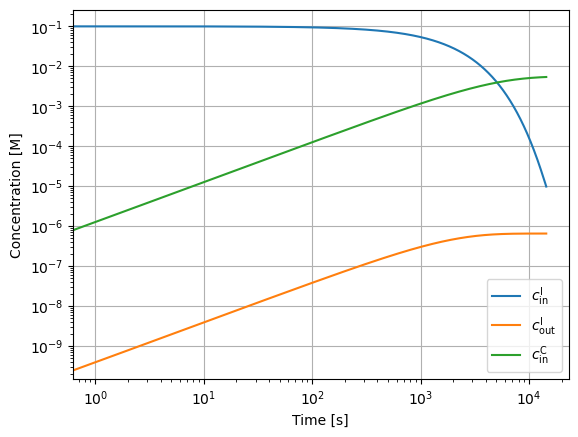

In [2]:
matplotlib.pyplot.close()

R = 2.5
A, Vₛ = compute_spore_area_and_volume_from_dia(2R)
K_cs = 0.001 # M
s_max = 0.1
ρₛ = inverse_mL_to_cubic_um(1e5) # spores/μm^3
V_out = 1/ρₛ - Vₛ
d_hp = 0.01
d_ps = 0.2
V_ps = 0.32 .* π .* ((R .- d_hp).^3 .- (R .- d_hp .- d_ps).^3)
Pₛ_I = 5e-4 # μm/s
Pₛ_C = 1e-5 # μm/s
c_ex_C = 0.00556 # M
c₀_I = 0.1 # M

# ODE function
function ode!(du, u, p, t)
    cinI, coutI, cinC = u

    # g = (p.K_cs + cinC * (1 + p.s_max)) * p.A / (p.K_cs + cinC)
    g = (1 + p.s_max * cinC / (p.K_cs + cinC)) * p.A
    rateI = g * p.Pₛ_I
    rateC = g * p.Pₛ_C

    du[1] = -(rateI / p.Vₛ) * (cinI - coutI)
    du[2] = (rateI / p.V_out) * (cinI - coutI)
    du[3] = -(rateC / p.V_ps) * (cinC - c_ex_C)
end

# Initial condition
u0 = [c₀_I, 0.0, 0.0] # [cinI, coutI, cinC]
p = (A=A, Vₛ=Vₛ, V_out=V_out, V_ps=V_ps, Pₛ_I=Pₛ_I, Pₛ_C=Pₛ_C, K_cs=K_cs, s_max=s_max, c_ex_C=c_ex_C)
tspan = (0.0, 14400.0)

# Integration
save_times = 0:1:14400
@time begin
    prob = ODEProblem(ode!, u0, tspan, p)
    sol = solve(prob, Tsit5(); saveat=save_times)
end
# sol = solve(prob, Rodas5())

sol_mat = reduce(hcat, sol.u)

# Molecules check
Nin = Vₛ .* sol_mat[1, :]
Nout = V_out .* sol_mat[2, :]
Ntot = Nin .+ Nout
println("Variance of inhibitor molecule count: ", var(Ntot))

# Plot concentration courses
fig, ax = subplots()
ax.loglog(sol.t, sol_mat[1, :], label=L"c_{\text{in}}^\text{I}")
ax.loglog(sol.t, sol_mat[2, :], label=L"c_{\text{out}}^\text{I}")
ax.loglog(sol.t, sol_mat[3, :], label=L"c_{\text{in}}^\text{C}")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Concentration [M]")
ax.grid(true)
ax.legend()
gcf()

### 1.2. Estimation of the germination probability

Due to the non-linearity in the ODEs, there is no closed-form analytical solution and the estimation of a germination probability becomes difficult. Some simplifications can be made if it is found that the ODE mapping is approximately linear when the spore radius $R$ and the initial inhibitor concentration $c_0^\textrm{I}$ vary randomly.

A straightforward test for this involves Monte Carlo sampling of the two varying parameters under observation of the output linearity.

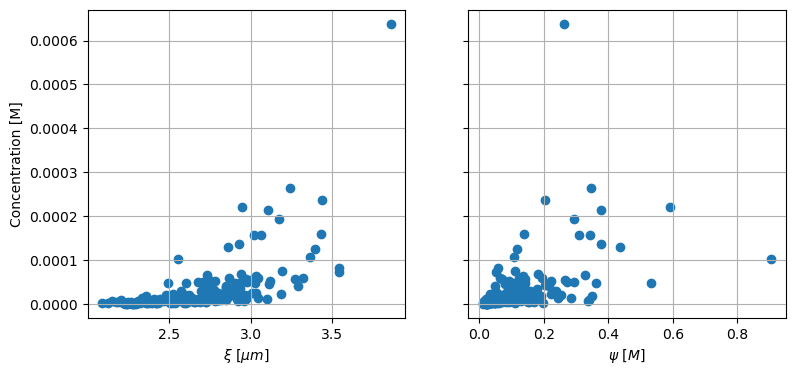

In [4]:
matplotlib.pyplot.close()

function c_in_inducer_dependent_permeability(t, ρₛ, R, d_hp, d_ps, c₀_I, c₀_C, Pₛ_I, Pₛ_C, s_max, K_cs)
    """
    Compute internal inhibitor concentration.
    inputs:
        t - time for evaluation in seconds
        ρₛ - spore density in spores/mL
        R - spore density in μm
        d_hp - hydrophobin layer thickness in μm
        d_ps - polysaccharide layer thickness in μm
        c₀_I - initial internal inhibitor concentration in M
        c₀_I - initial external inducer concentration in M
        Pₛ_I - inhibitor permeation constant in μm/s
        Pₛ_C - inducer permeation constant in μm/s
        s_max - maximum inductive signal strength
        K_cs - half-saturation constant for the carbon source in M
    """

    A, Vₛ = compute_spore_area_and_volume_from_dia(2*R)
    ρₛ = inverse_mL_to_cubic_um(ρₛ) # spores/mL
    V_out = 1/ρₛ - Vₛ
    V_ps = 0.32 .* π .* ((R .- d_hp).^3 .- (R .- d_hp .- d_ps).^3)

    # ODE function
    function ode!(du, u, p, t)
        cinI, coutI, cinC = u

        # g = (K_cs + cinC * (1 + s_max)) * A / (K_cs + cinC)
        g = (1 + s_max * cinC / (K_cs + cinC)) * A
        rateI = g * Pₛ_I
        rateC = g * Pₛ_C

        du[1] = -(rateI / Vₛ) * (cinI - coutI)
        du[2] = (rateI / V_out) * (cinI - coutI)
        du[3] = -(rateC / V_ps) * (cinC - c_ex_C)
    end

    u0 = [c₀_I, 0.0, 0.0]
    tspan = (0.0, t)

    prob = ODEProblem(ode!, u0, tspan)
    sol = solve(prob, Tsit5())

    return sol.u[end][1]
end

# Random samples
n_samples = 200

μ_ξ = 2.65
σ_ξ = 0.3
μ_ξ_log = log(μ_ξ^2 / sqrt(σ_ξ^2 + μ_ξ^2))
σ_ξ_log = sqrt(log(σ_ξ^2 / μ_ξ^2 + 1))
dist_ξ = LogNormal(μ_ξ_log, σ_ξ_log)
samples_ξ = rand(dist_ξ, n_samples)

μ_ψ = 0.1
σ_ψ = 0.1
μ_ψ_log = log(μ_ψ^2 / sqrt(σ_ψ^2 + μ_ψ^2))
σ_ψ_log = sqrt(log(σ_ψ^2 / μ_ψ^2 + 1))
dist_ψ = LogNormal(μ_ψ_log, σ_ψ_log)
samples_ψ = rand(dist_ψ, n_samples)

t_max = 14400
samples_c_in = zeros(n_samples)
for n in 1:n_samples
    samples_c_in[n] = c_in_inducer_dependent_permeability(t_max, inverse_mL_to_cubic_um(1e5), samples_ξ[n], d_hp, d_ps, samples_ψ[n], c_ex_C, Pₛ_I, Pₛ_C, s_max, K_cs)
end

# Plot samples
fig, ax = subplots(1, 2, figsize=(9, 4), sharey=true)
ax[1].grid(true)
ax[2].grid(true)
ax[1].scatter(samples_ξ, samples_c_in)
ax[2].scatter(samples_ψ, samples_c_in)
ax[1].set_xlabel(L"\xi \ [\mu m]")
ax[1].set_ylabel("Concentration [M]")
ax[2].set_xlabel(L"\psi \ [M]")
# ax.grid(true)
gcf()

The scatter plots demonstrate clearly that the ODE mapping is not linear both $\psi$ and $\xi$. Therefore, a linear approximation is not feasible and Monte Carlo sampling appears the best way to integrate the germination probabilities. The case observed below is an inhibitor-dependent germination with an inducer-dependent cell wall permeability. Hence, $\gamma$ is added as a random parameter. It is investigated at what sample size the solution converges to a stable value by measuring the variance of 50 runs per sample size.

The sampling is performed using shuffled Sobol sequences.

In [6]:
# Fixed parameters
K_cs = 0.001 # M
s_max = 0.1
ρₛ = inverse_mL_to_cubic_um(1e5) # spores/μm^3
Pₛ_I = 5e-4 # μm/s
Pₛ_C = 1e-5 # μm/s
c_ex_C = 0.00556 # M
d_hp = 0.01 # μm
d_ps = 0.2 # μm

t_query = 14400
n_sample_range = 2 .^ (3:15)
n_runs = 50

μ_ξ = 2.65
σ_ξ = 0.3
μ_ψ = 0.1
σ_ψ = 0.1
μ_γ = 1e-2
σ_γ = 1e-3

# Template problem
dummyA, dummyV = compute_spore_area_and_volume_from_dia(2*μ_ξ)
p_template = (A=dummyA, Vₛ=dummyV, V_out=1.0/ρₛ - dummyV, V_ps=0.32 .* π .* ((R .- d_hp).^3 .- (R .- d_hp .- d_ps).^3),
              Pₛ_I=Pₛ_I, Pₛ_C=Pₛ_C, K_cs=K_cs, s_max=s_max, c_ex_C=c_ex_C)
u0_template = [μ_ψ, 0.0, 0.0]
tspan = (0.0, t_query)
prob = ODEProblem(ode!, u0_template, tspan, p_template)

pct_means = zeros(length(n_sample_range))
pct_vars = zeros(length(n_sample_range))

for (i, n_samples) in enumerate(n_sample_range)

    println("Running sample size ", n_samples)
    
    pcts = zeros(n_runs)

    for j in 1:n_runs

        # Random samples
        sobol_pts = QuasiMonteCarlo.sample(n_samples, 3, SobolSample(R = OwenScramble(base = 2, pad = 2+i)))
        
        μ_ξ_log = log(μ_ξ^2 / sqrt(σ_ξ^2 + μ_ξ^2))
        σ_ξ_log = sqrt(log(σ_ξ^2 / μ_ξ^2 + 1))
        dist_ξ = LogNormal(μ_ξ_log, σ_ξ_log)
        samples_ξ = max.(quantile(dist_ξ, sobol_pts[1,:]), 1e-12)

        μ_ψ_log = log(μ_ψ^2 / sqrt(σ_ψ^2 + μ_ψ^2))
        σ_ψ_log = sqrt(log(σ_ψ^2 / μ_ψ^2 + 1))
        dist_ψ = LogNormal(μ_ψ_log, σ_ψ_log)
        samples_ψ = max.(quantile(dist_ψ, sobol_pts[2,:]), 1e-12)

        μ_γ_log = log(μ_γ^2 / sqrt(σ_γ^2 + μ_γ^2))
        σ_γ_log = sqrt(log(σ_γ^2 / μ_γ^2 + 1))
        dist_γ = LogNormal(μ_γ_log, σ_γ_log)
        samples_γ = max.(quantile(dist_γ, sobol_pts[3,:]), 1e-12)

        samples_AV = compute_spore_area_and_volume_from_dia.(2 .* samples_ξ)
        samples_A, samples_Vₛ = (map(x -> x[1], samples_AV), map(x -> x[2], samples_AV))
        samples_V_out = 1.0 / ρₛ .- samples_Vₛ
        samples_V_ps = compute_ps_layer_volume.(samples_ξ, d_hp, d_ps)

        # println(samples_A[1:5])
        # println(samples_Vₛ[1:5])
        # println(samples_V_out[1:5])
        # println(samples_V_ps[1:5])

        function prob_func(prob, i, repeat)
            r = max(samples_ξ[i], 1e-9)

            new_p = (A=samples_A[i], Vₛ=samples_Vₛ[i], V_out=samples_V_out[i], V_ps=samples_V_ps[i],
                Pₛ_I=Pₛ_I, Pₛ_C=Pₛ_C, K_cs=K_cs, s_max=s_max, c_ex_C=c_ex_C)

            new_u0 = [samples_ψ[i], 0.0, 0.0]
            remake(prob; u0 = new_u0, p = new_p)
        end

        # Run ODE ensembles
        ep = EnsembleProblem(prob; prob_func=prob_func)
        sols = solve(ep, Rodas5(), EnsembleThreads(), trajectories=n_samples, saveat=[t_query])

        # Evaluate fraction germinated
        c_inI_at_t = [ sols[i](t_query)[1] for i in 1:n_samples ]
        # println("Mean internal inhibitor concentration: ", mean(c_inI_at_t))
        germinated = c_inI_at_t .< samples_γ
        pct = 100 * mean(germinated)
        # println("Percent germinated: ", pct)

        pcts[j] = pct
    end

    pct_means[i] = mean(pcts)
    pct_vars[i] = var(pcts)
end

Running sample size 8
Running sample size 16
Running sample size 32
Running sample size 64
Running sample size 128
Running sample size 256
Running sample size 512
Running sample size 1024
Running sample size 2048
Running sample size 4096
Running sample size 8192
Running sample size 16384
Running sample size 32768


[21.428571428571427, 6.377551020408164, 0.3826530612244898, 0.0, 0.02391581632653061, 0.005978954081632653, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


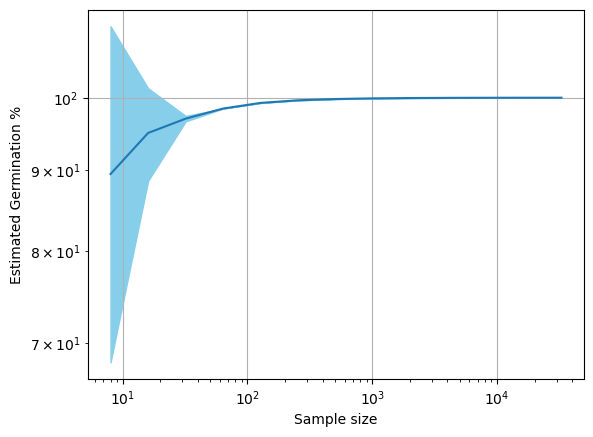

In [7]:
println(pct_vars)
fig, ax = subplots()
ax.loglog(n_sample_range, pct_means)
ax.fill_between(n_sample_range, pct_means .- pct_vars, pct_means .+ pct_vars, color="skyblue")
ax.grid()
# ax.set_ylim(0, 10)
ax.set_xlabel("Sample size")
ax.set_ylabel("Estimated Germination %")
gcf()

It is thus visible that the variance converges at about $\mathcal{O}(10^3)$ samples, while the mean stabilizes at about $\mathcal{O}(10^4)$ samples. The lower sample size can be taken as sufficiently accurate for the practical purposes.

This enables a performance test of a parameter estimation procedure with the developed model. First, a typical time evolution of the germination percentage is explored using exemplary parameter values.

In [5]:
model_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05,
    :Pₛ => 5e-4,
    :Pₛ_cs => 1e-5,
    :μ_γ => 1e-3,
    :σ_γ => 1e-4,
    :K_cs => 1.0,
    :s_max => 0.5,
    :μ_ψ => 0.5,
    :σ_ψ => 0.01
)

t_max_eval = 5*3600
times_eval = LinRange(0, t_max_eval, 100)
density_test = inverse_mL_to_cubic_um(1e5)

p_out = compute_germination_response("feedback_inhibitor_perm", times_eval, density_test, model_params)

100-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0

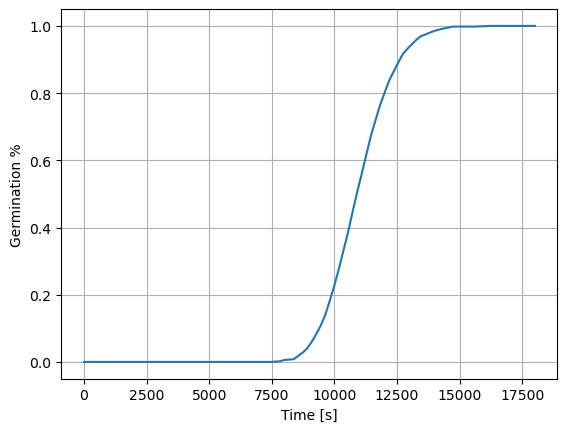

In [6]:
matplotlib.pyplot.close()

fig, ax = subplots()

ax.plot(times_eval, p_out)
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

As a next step, the previously used parameter optimisation procedure is applied on the current model.

In [2]:
t_max = 48
df_germination_rebuilt = parse_ijadpanahsaravi_data()
df_germination_rebuilt = filter(row -> row[1] != "Arg", df_germination_rebuilt) # Remove "Arg" from the dataset
dantigny_data, times, sources, densities, errs, p_maxs, taus, nus = generate_dantigny_dataset(df_germination_rebuilt, t_max)

# Define default parameters globally
def_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05
)

# Define parameter bounds globally
bounds_narrow = Dict(
    :s_max => (1e-4, 1e4),
    :b_max => (1e-4, 1.0),
    :Pₛ => (1e-4, 1e-3),
    :Pₛ_cs => (1e-7, 1e-2),
    :k_C => (-6, 6),
    :k_I => (-6, 6),
    :K_I => (1e-5, 1.0),
    :K_cC => (1e-8, 0.1),
    :K_cI => (1e-8, 0.1),
    :n => (1.0, 3.0),
    :s => (1e-6, 1.0),
    :μ_γ => (1e-6, 1e-4),
    :δ_γ => (-10, -0.5),
    :μ_ω => (1e-6, 10.0),
    :δ_ω => (-10, -0.5),
    :μ_ψ => (1e-5, 1.0),	
    :δ_ψ => (-10, 0),
    :μ_π => (1e-4, 1e-3),
    :δ_π => (-10, 0),
    :μ_α => (1e-4, 1.0),
    :δ_α => (-10, 0)
)

bounds_broad = Dict(
    :s_max => (1e-4, 1e4),
    :b_max => (1e-4, 1.0),
    :Pₛ => (1e-5, 1e-2),
    :Pₛ_cs => (1e-8, 1e-2),
    :k_C => (-6, 6),
    :k_I => (-6, 6),
    :K_I => (1e-5, 1.0),
    :K_cC => (1e-8, 10.0),
    :K_cI => (1e-8, 10.0),
    :n => (1.0, 3.0),
    :s => (1e-6, 1.0),
    :μ_γ => (1e-8, 1e-1),
    :δ_γ => (-10, -0.5),
    :μ_ω => (1e-6, 10.0),
    :δ_ω => (-10, -0.5),
    :μ_ψ => (1e-5, 1.0),	
    :δ_ψ => (-10, 0),
    :μ_π => (1e-4, 1e-3),
    :δ_π => (-10, 0),
    :μ_α => (1e-4, 1.0),
    :δ_α => (-10, 0)
)

Dict{Symbol, Tuple{Real, Real}} with 21 entries:
  :K_I   => (1.0e-5, 1.0)
  :n     => (1.0, 3.0)
  :δ_ω   => (-10, -0.5)
  :μ_ψ   => (1.0e-5, 1.0)
  :μ_α   => (0.0001, 1.0)
  :δ_ψ   => (-10, 0)
  :δ_α   => (-10, 0)
  :μ_ω   => (1.0e-6, 10.0)
  :μ_π   => (0.0001, 0.001)
  :Pₛ    => (1.0e-5, 0.01)
  :s     => (1.0e-6, 1.0)
  :δ_π   => (-10, 0)
  :k_I   => (-6, 6)
  :b_max => (0.0001, 1.0)
  :k_C   => (-6, 6)
  :K_cI  => (1.0e-8, 10.0)
  :δ_γ   => (-10, -0.5)
  :K_cC  => (1.0e-8, 10.0)
  :μ_γ   => (1.0e-8, 0.1)
  ⋮      => ⋮

In [ ]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_inhibitor_inducer_perm", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_inhibitor_inducer_perm.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: inhibitor-dependent germination with inducer-dependent inhibitor/inducer permeability
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
8.00 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=847.430745333
15.10 secs, 4 evals, 2 steps, improv/step: 0.500 (last = 0.0000), fitness=847.430745333
23.00 secs, 6 evals, 3 steps, improv/step: 0.667 (last = 1.0000), fitness=847.430745333
30.48 secs, 8 evals, 4 steps, improv/step: 0.750 (last = 1.0000), fitness=847.430745333
37.14 secs, 10 evals, 5 steps, improv/step: 0.600 (last = 0.0000), fitness=847.430745333
44.48 secs, 12 evals, 6 steps, improv/step: 0.500 (last = 0.0000), fitness=847.430745333
48.03 secs, 13 evals, 7 steps, improv/ste

Dict{Any, Any} with 8 entries:
  :σ_γ   => [1.43929e-5]
  :σ_ψ   => [0.965951]
  :K_cs  => [0.0918654, 0.0496924]
  :μ_ψ   => [0.970265]
  :μ_γ   => [2.37299e-5]
  :s_max => [506.593, 5078.56]
  :Pₛ    => [0.000168275]
  :Pₛ_cs => [0.00914171, 0.000195457]

0.24057576643909578


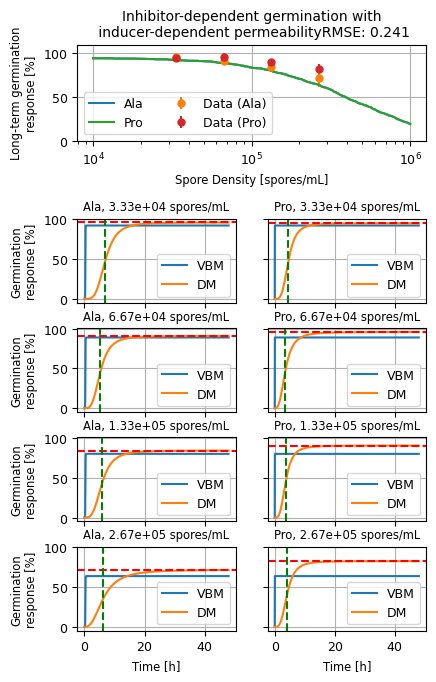

In [ ]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_inhibitor_inducer_perm.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_inhibitor_inducer_perm", params_test, times, sources, densities, p_maxs, taus, nus, errs, n_nodes=1024)

## 2. Remaining feedback models

The main difference among the remaining feedback models lies in the formulation of the ODEs. The following sections outline the governing equations and attempt a systematic completion of all model variants.

### 2.1. Single-interaction models

#### 2.1.1. Inducer-dependent cell wall permeability (A)

The ODEs for this scenario were outlined in Section 1. Two possible variants exist:
- 2-factor germination;
- inhibitor-dependent germination (already explored).

In [14]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_combined_inducer_perm", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_combined_inducer_perm.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: 2-factor germination with inducer-dependent inhibitor/inducer permeability
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
10.35 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=886.772924414
21.82 secs, 4 evals, 2 steps, improv/step: 0.500 (last = 0.0000), fitness=805.483768581
33.79 secs, 6 evals, 3 steps, improv/step: 0.667 (last = 1.0000), fitness=805.483768581
44.71 secs, 8 evals, 4 steps, improv/step: 0.750 (last = 1.0000), fitness=805.483768581
56.23 secs, 10 evals, 5 steps, improv/step: 0.800 (last = 1.0000), fitness=805.483768581
66.82 secs, 12 evals, 6 steps, improv/step: 0.833 (last = 1.0000), fitness=805.483768581
79.07 secs, 14 evals, 7 steps, improv/step: 0.714 (

Dict{Any, Any} with 10 entries:
  :σ_γ   => [1.83044e-5]
  :σ_ω   => [4.642, 5.34494]
  :σ_ψ   => [0.027509]
  :μ_ω   => [7.65336, 8.99385]
  :K_cC  => [0.0383299, 0.0563683]
  :μ_ψ   => [0.977683]
  :s_max => [5454.07, 5190.32]
  :Pₛ    => [0.000415203]
  :Pₛ_cs => [0.00846824, 0.00197077]
  :μ_γ   => [3.01796e-5]

0.24110278075162575


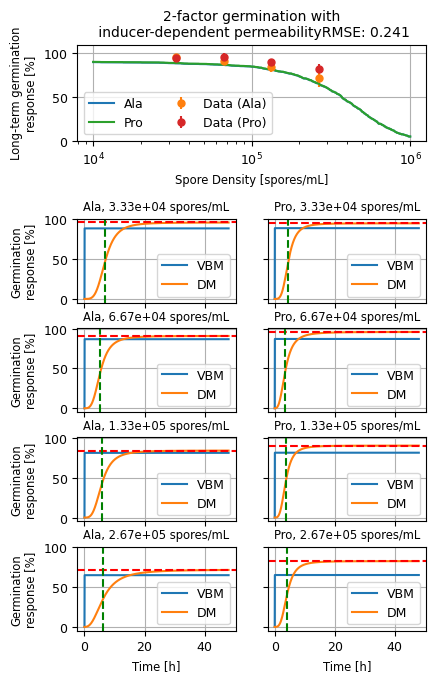

In [15]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_combined_inducer_perm.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_combined_inducer_perm", params_test, times, sources, densities, p_maxs, taus, nus, errs, n_nodes=1024)

#### 2.1.2. Inhibitor-dependent cell wall permeability (D)

It has been observed that 1-octen-3-ol increases the cell membrane permeability. If this also affects the overall permeability through the spore envelope, then a similar ODE system can be developed as before:

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{I}}=-\frac{g(c_{\textrm{in}}^{\textrm{I}}) P_s^{\textrm{I}}}{V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right]
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{out}}^{\textrm{I}}=\frac{g(c_{\textrm{in}}^{\textrm{I}}) P_s^{\textrm{I}}}{1/\rho_s-V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{C}}=-\frac{g(c_{\textrm{in}}^{\textrm{I}}) P_s^{\textrm{C}}}{V_{\textrm{ps}}}\left[c_{\textrm{in}}^{\textrm{C}}(t)-c_{\textrm{ex}}^{\textrm{C}}\right],
\end{equation}
$$

where

$$
g(c_{\textrm{in}}^{\textrm{I}})=\left(1-b_{\textrm{max}}\frac{c_{\textrm{in}}^{\textrm{I}}}{K_{\textrm{cI}}+c_{\textrm{in}}^{\textrm{I}}}\right)A=\frac{K_{\textrm{cI}}+c_{\textrm{in}}^{\textrm{I}}(1-b_{\textrm{max}})}{K_{\textrm{cI}}+c_{\textrm{in}}^{\textrm{I}}}A,
$$

a Michaelis-Menten modulation of the permeability through the inhibitor concentration, where $0\le b_{\textrm{max}}\le 1$.

This scenario may apply to two types of germination trigger:
- 2-factor germination;
- inducer-dependent germination.

In [9]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_inducer_inhibitor_perm", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_inducer_inhibitor_perm.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: Inducer-dependent germination with inhibitor-dependent inhibitor/inducer permeability
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
7.52 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=890.772924414
15.21 secs, 4 evals, 2 steps, improv/step: 0.500 (last = 0.0000), fitness=890.563987903
22.49 secs, 6 evals, 3 steps, improv/step: 0.667 (last = 1.0000), fitness=890.563987903
30.01 secs, 8 evals, 4 steps, improv/step: 0.500 (last = 0.0000), fitness=890.563987903
37.39 secs, 10 evals, 5 steps, improv/step: 0.600 (last = 1.0000), fitness=890.563987903
44.46 secs, 12 evals, 6 steps, improv/step: 0.667 (last = 1.0000), fitness=890.563987903
47.28 secs, 13 evals, 7 steps, improv/ste

Dict{Any, Any} with 8 entries:
  :b_max => [0.560763]
  :σ_ψ   => [0.73902]
  :K_cI  => [0.035667]
  :μ_ω   => [0.0156963, 4.99739]
  :μ_ψ   => [0.857128]
  :Pₛ    => [0.0007316]
  :σ_ω   => [0.00926296, 0.0328949]
  :Pₛ_cs => [0.00409908, 0.00536558]

0.27392166086420605


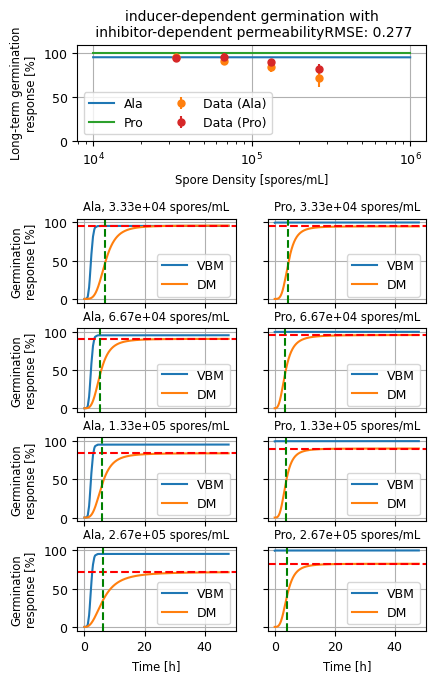

In [10]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_inducer_inhibitor_perm.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_inducer_inhibitor_perm", params_test, times, sources, densities, p_maxs, taus, nus, errs, n_nodes=1024)

In [11]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_combined_inhibitor_perm", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_combined_inhibitor_perm.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: 2-factor germination with inhibitor-dependent inhibitor/inducer permeability
Running first optimisation stage
Starting optimization with optimizer BlackBoxOptim.DiffEvoOpt{BlackBoxOptim.FitPopulation{Float64}, BlackBoxOptim.RadiusLimitedSelector, BlackBoxOptim.AdaptiveDiffEvoRandBin{3}, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
10.13 secs, 2 evals, 1 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
18.95 secs, 4 evals, 2 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
28.45 secs, 6 evals, 3 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
37.12 secs, 8 evals, 4 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
41.29 secs, 9 evals, 5 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
50.31 secs, 11 evals, 6 steps, improv/step: 1.000 (last = 1.0000), fitness=5296.501323631
59.03 secs, 13 evals, 7 steps, improv/step: 

Dict{Any, Any} with 10 entries:
  :σ_γ   => [1.34733e-5]
  :b_max => [0.038061]
  :σ_ψ   => [0.000642106]
  :K_cI  => [0.096301]
  :μ_ω   => [5.74834, 6.6342]
  :μ_ψ   => [0.999554]
  :μ_γ   => [4.30574e-5]
  :Pₛ    => [0.000699166]
  :σ_ω   => [0.869621, 0.860379]
  :Pₛ_cs => [0.00290059, 0.00765398]

0.8136723329780117


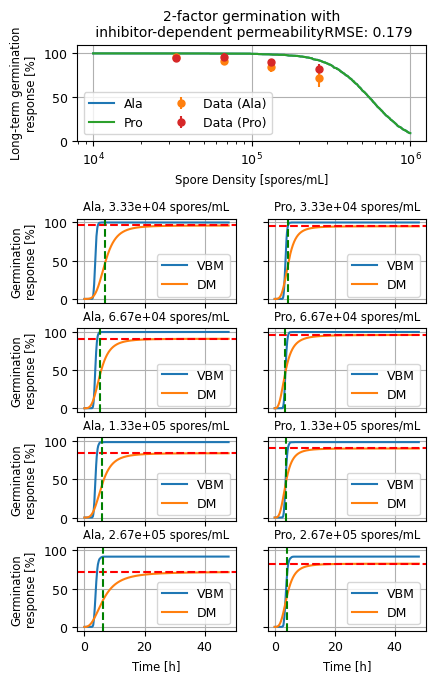

In [12]:
matplotlib.pyplot.close()

# Load the fitted parameters
t_max, def_params_opt, bounds_opt, params_opt, max_steps_opt, rmse = jldopen("../src/Data/fit_feedback_combined_inhibitor_perm.jld2", "r") do file
    return file["t_max"], file["def_params"], file["bounds"], file["params_opt"], file["max_steps"], file["rmse"]
end

println(rmse)

# Load default and fitted parameters
params_test = merge(def_params, params_opt)

plot_germination_data_fit_all("feedback_combined_inhibitor_perm", params_test, times, sources, densities, p_maxs, taus, nus, errs, n_nodes=1024)

### 2.2. Double-interaction models

#### 2.2.1. Inducer-dependent cell wall permeability and inhibition threshold (AB)

The ODEs for this scenario are the same as in Section 1, but the inhibition threshold is additionally shifted by an amount proportional to the time-dependent inducer concentration. The applicable triggering variants are:
- 2-factor germination;
- inhibitor-dependent germination.

In [23]:
model_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05,
    :Pₛ => 5e-4,
    :Pₛ_cs => 1e-5,
    :μ_γ => 1e-3,
    :σ_γ => 1e-4,
    :K_cs => 1.0,
    :s_max => 0.5,
    :μ_ψ => 0.5,
    :σ_ψ => 0.01,
    :K_cC => 0.01,
    :k_C => 0.1
)

t_max_eval = 5*3600
times_eval = LinRange(0, t_max_eval, 100)
density_test = inverse_mL_to_cubic_um(1e5)

p_out = compute_germination_response("feedback_inhibitor_inducer_perm_thresh", times_eval, density_test, model_params)

(100,)
(1,)
(1024,)
(1, 1024)
()
(1,)
(100,)
(1, 1024)


MethodError: MethodError: no method matching +(::Float64, ::LinearAlgebra.Adjoint{Float64, Vector{Float64}})
For element-wise addition, use broadcasting with dot syntax: scalar .+ array

Closest candidates are:
  +(::Any, ::Any, !Matched::Any, !Matched::Any...)
   @ Base operators.jl:587
  +(!Matched::PyCall.PyObject, ::Any)
   @ PyCall C:\Users\mihbo\.julia\packages\PyCall\1gn3u\src\pyoperators.jl:13
  +(::Any, !Matched::ChainRulesCore.ZeroTangent)
   @ ChainRulesCore C:\Users\mihbo\.julia\packages\ChainRulesCore\Vsbj9\src\tangent_arithmetic.jl:100
  ...


In [3]:
max_steps = 10
params_opt, rmse = fit_model_to_data("feedback_inhibitor_inducer_perm_thresh", def_params, dantigny_data, times, sources, densities, bounds_narrow, max_steps=max_steps)

jldopen("../src/Data/fit_feedback_inhibitor_inducer_perm_thresh.jld2", "w") do file
    file["t_max"] = t_max
    file["def_params"] = def_params
    file["bounds"] = bounds_narrow
    file["params_opt"] = params_opt
    file["max_steps"] = max_steps
    file["rmse"] = rmse
end

params_opt

Number of nodes/samples: 1024
Model: inhibitor-dependent germination with inducer-dependent permeability and inhibition threshold
Running first optimisation stage


MethodError: MethodError: no method matching +(::Vector{Float64}, ::Float64)
For element-wise addition, use broadcasting with dot syntax: array .+ scalar

Closest candidates are:
  +(::Any, ::Any, !Matched::Any, !Matched::Any...)
   @ Base operators.jl:587
  +(!Matched::P, ::S) where {S<:Number, T, X, P<:Polynomials.FactoredPolynomial{T, X}}
   @ Polynomials C:\Users\mihbo\.julia\packages\Polynomials\OrxjN\src\polynomials\factored_polynomial.jl:272
  +(!Matched::PyCall.PyObject, ::Any)
   @ PyCall C:\Users\mihbo\.julia\packages\PyCall\1gn3u\src\pyoperators.jl:13
  ...


#### 2.2.2. Inducer-dependent cell wall permeability and inhibitor-dependent induction strength (AC)

This double feedback loop combines a self-modulation of the induction strength via the cell wall permeability and via the accumulation of inhibitor. The ODEs are

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{I}}=-\frac{g(c_{\textrm{in}}^{\textrm{C}}) P_s^{\textrm{I}}}{V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right]
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{out}}^{\textrm{I}}=\frac{g(c_{\textrm{in}}^{\textrm{C}}) P_s^{\textrm{I}}}{1/\rho_s-V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{C}}=-\frac{g(c_{\textrm{in}}^{\textrm{C}}) P_s^{\textrm{C}}}{V_{\textrm{ps}}}\left[c_{\textrm{in}}^{\textrm{C}}(t)-c_{\textrm{ex}}^{\textrm{C}}\right],
\end{equation}
$$

where

$$
g(c_{\textrm{in}}^{\textrm{C}})=\left(1+s'\frac{c_{\textrm{in}}^{\textrm{C}}}{K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}}\right)A, \quad s'=s_{\textrm{max}}\left[\frac{1}{1+\left(\frac{c_{\textrm{in}}^{\textrm{I}}}{K_I}\right)^n}\right].
$$

This model applies to
- 2-factor germination;
- inhibitor-dependent germination;
- inducer-dependent germination.

#### 2.2.3. Inducer- and inhibitor-dependent cell wall permeability (AD)

In this scenario, the cell wall permeability is simultaneously modulated by the inducer and by the inhibitor concentration. The ODEs take the form

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{I}}=-\frac{g(c_{\textrm{in}}^{\textrm{C}}, c_{\textrm{in}}^{\textrm{I}}) P_s^{\textrm{I}}}{V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right]
\end{equation}
$$

$$  
\begin{equation}
\dot{c}_{\textrm{out}}^{\textrm{I}}=\frac{g(c_{\textrm{in}}^{\textrm{C}}, c_{\textrm{in}}^{\textrm{I}}) P_s^{\textrm{I}}}{1/\rho_s-V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{C}}=-\frac{g(c_{\textrm{in}}^{\textrm{C}}, c_{\textrm{in}}^{\textrm{I}}) P_s^{\textrm{C}}}{V_{\textrm{ps}}}\left[c_{\textrm{in}}^{\textrm{C}}(t)-c_{\textrm{ex}}^{\textrm{C}}\right],
\end{equation}
$$

where

$$
g(c_{\textrm{in}}^{\textrm{C}})=\left(1+s_{\textrm{max}}\frac{c_{\textrm{in}}^{\textrm{C}}}{K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}}-k\frac{c_{\textrm{in}}^{\textrm{I}}}{K_{\textrm{I}}+c_{\textrm{in}}^{\textrm{I}}}\right)A.
$$

This model applies to
- 2-factor germination;
- inhibitor-dependent germination;
- inducer-dependent germination.

#### 2.2.4. Inducer-dependent cell wall permeability and inhibitor-dependent induction threshold (AE)

This scenarios follows the ODEs from Section 1, but the germination criterion is with respect to a dynamic inhibitor-dependent induction threshold. The two triggering variants are
- 2-factor germination;
- inducer-dependent germination.

#### 2.2.5. Inhibitor-dependent induction signal and inducer-dependent inhibition threshold (BC)

Since none of the interactions affects the inducer or inhibitor concentration, the two compound amounts can be computed analytically. However, the inhibition threshold changes dynamically with the inducer signal, which in the case of a 2-factor germination leads to the probability equation:

$$
\begin{equation}
    p=\int_0^\infty{\int_0^\infty{\int_0^\infty{\left[1-\Phi{\left(z_{\gamma_0}\right)}\right]\Phi{\left(z_{\omega}\right)}\ f_\kappa{(\kappa)}\ f_\psi{(\psi)}\ f_\xi{(\xi)}\ d{\kappa}}\ d{\psi}}\ d{\xi}},
\end{equation}
$$

where

$$
\begin{equation}
    z_{\gamma_0}=\frac{\beta-ks{(\xi, \kappa)}\left[1+\left(\frac{c_{\textrm{in}}^{\textrm{I}}{(\xi,\psi)}}{K_I}\right)^n\right]^{-1}-\mu_{\gamma_0}}{\sigma_{\gamma_0}}
\end{equation}
$$

and

$$
\begin{equation}
    z_\omega=\frac{s{(\xi, \kappa)}\left[1+\left(\frac{c_{\textrm{in}}^{\textrm{I}}{(\xi,\psi)}}{K_I}\right)^n\right]^{-1}-\mu_{\omega}}{\sigma_{\omega}}.
\end{equation}
$$

Another option is a solely inhibitor-dependent germination, yielding

$$
\begin{equation}
    p=\int_0^\infty{\int_0^\infty{\int_0^\infty{\left[1-\Phi{\left(z_{\gamma_0}\right)}\right]\ f_\kappa{(\kappa)}\ f_\psi{(\psi)}\ f_\xi{(\xi)}\ d{\kappa}}\ d{\psi}}\ d{\xi}}.
\end{equation}
$$

#### 2.2.6. Inhibitor-dependent cell wall permeability and inducer-dependent inhibition threshold (BD)

The ODEs for this scenario are as in 2.1.2. and the germination criterion involves a dynamic threshold shifted by the inductive signal. The germination triggering occurs through
- 2-factor germination;
- inhibitor-dependent germination.

#### 2.2.7. Inducer-dependent inhibition threshold and inhibitor-dependent induction threshold (BE)

The inducer/inhibitor concentrations in this case are not influenced by each other, but both thresholds are affected. This results in an analytical solution:

$$
\begin{equation}
    p=\int_0^\infty{\int_0^\infty{\int_0^\infty{\left[1-\Phi{\left(z_{\gamma_0}\right)}\right]\Phi{\left(z_{\omega_0}\right)}\ f_\kappa{(\kappa)}\ f_\psi{(\psi)}\ f_\xi{(\xi)}\ d{\kappa}}\ d{\psi}}\ d{\xi}},
\end{equation}
$$

where

$$
\begin{equation}
    z_{\gamma_0}=\frac{\beta-k_1s{(\xi, \kappa)}-\mu_{\gamma_0}}{\sigma_{\gamma_0}}
\end{equation}
$$

and

$$
\begin{equation}
    z_{\omega_0}=\frac{s{(\xi, \kappa)}-k_2c_{\textrm{in}}^{\textrm{I}}{(\xi,\psi)}-\mu_{\omega_0}}{\sigma_{\omega_0}}.
\end{equation}
$$

Note the two _different_ proportionality constants for the respective threshold shifts ($k_1$ and $k_2$).

#### 2.2.8. Inducer-dependent cell wall permeability and induction signal (CD)

The ODEs for this system are as in 2.1.2., but additionally the inducer concentration is multiplied by the inhibitor effect before performing the induction threshold check. This applies to
- 2-factor germination;
- inducer-dependent germination.

#### 2.2.9. Inhibitor-dependent cell wall permeability and induction threshold (DE)

The ODEs for this system are as in 2.1.2., with an inhibitor-dependent induction threshold changing over time. This applies to
- 2-factor germination;
- inducer-dependent germination.

### 2.3. Triple-interaction models

#### 2.3.1. Inducer-dependent cell wall permeability and inhibition threshold, inhibitor-dependent induction signal (ABC)

The ODEs are as in 2.2.2., with the inhibition threshold being dynamically modulated by the inductive signal. The system applies to
- 2-factor germination;
- inhibitor-dependent germination.

#### 2.3.2. Inducer and inhibitor-dependent cell wall permeability, inducer-dependent inhibition threshold (ABD)

The ODEs are as in 2.2.3, with the inhibition threshold being dynamically modulated by the inductive signal. The system applies to
- 2-factor germination;
- inhibitor-dependent germination.

#### 2.3.3. Inducer-dependent cell wall permeability and inhibition threshold, inhibitor-dependent induction threshold (ABE)

The ODEs are as in Section 1 and both thresholds are dynamically modulated by the opposite actor. The only triggering variant is 2-factor germination.

#### 2.3.4. Inducer and inhibitor-dependent cell wall permeability, inhibitor-dependent induction signal (ACD)

The ODE system is as follows:

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{I}}=-\frac{g(c_{\textrm{in}}^{\textrm{C}}, c_{\textrm{in}}^{\textrm{I}}) P_s^{\textrm{I}}}{V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right]
\end{equation}
$$

$$  
\begin{equation}
\dot{c}_{\textrm{out}}^{\textrm{I}}=\frac{g(c_{\textrm{in}}^{\textrm{C}}, c_{\textrm{in}}^{\textrm{I}}) P_s^{\textrm{I}}}{1/\rho_s-V_s}\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

$$
\begin{equation}
\dot{c}_{\textrm{in}}^{\textrm{C}}=-\frac{g(c_{\textrm{in}}^{\textrm{C}}, c_{\textrm{in}}^{\textrm{I}}) P_s^{\textrm{C}}}{V_{\textrm{ps}}}\left[c_{\textrm{in}}^{\textrm{C}}(t)-c_{\textrm{ex}}^{\textrm{C}}\right],
\end{equation}
$$

where

$$
g(c_{\textrm{in}}^{\textrm{C}})=\left(1+s_{\textrm{max}}\frac{c_{\textrm{in}}^{\textrm{C}}}{K_{\textrm{cs}}+c_{\textrm{in}}^{\textrm{C}}}\left[1+\left(\frac{c_{\textrm{in}}^{\textrm{I}}{(\xi,\psi)}}{K_I}\right)^n\right]^{-1}-k\frac{c_{\textrm{in}}^{\textrm{I}}}{K_{\textrm{I}}+c_{\textrm{in}}^{\textrm{I}}}\right)A.
$$

This model applies to
- 2-factor germination;
- inhibitor-dependent germination;
- inducer-dependent germination.

#### 2.3.5. Inducer-dependent cell wall permeability, inhibitor-dependent induction signal and threshold (ACE)

The ODEs are as in 2.2.2. and the induction threshold is dynamically modulated by the inhibitor concentration. The system applies to
- 2-factor germination;
- inducer-dependent germination.

#### 2.3.6. Inducer and inhibitor-dependent cell wall permeability, inhibitor-dependent induction threshold (ADE)

The ODEs are as in 2.2.3. and the induction threshold is dynamically modulated by the inhibitor concentration. The system applies to
- 2-factor germination;
- inducer-dependent germination.

#### 2.3.7. Inhibitor-dependent cell wall permeability and induction signal, inducer-dependent inhibition threshold (BCD)

The ODEs are as in 2.1.2., the induction signal is dynamically modulated by the inhibition concentration and the inhibition threshold in dynamically modulated by the inducing signal. The system applies to
- 2-factor germination;
- inhibitor-dependent germination.

#### 2.3.8. Inhibitor-dependent induction signal and threshold, inducer-dependent inhibition threshold (BCE)

This model has an analytical solution and only applies to 2-factor germination:

$$
\begin{equation}
    p=\int_0^\infty{\int_0^\infty{\int_0^\infty{\left[1-\Phi{\left(z_{\gamma_0}\right)}\right]\Phi{\left(z_{{\omega_0}}\right)}\ f_\kappa{(\kappa)}\ f_\psi{(\psi)}\ f_\xi{(\xi)}\ d{\kappa}}\ d{\psi}}\ d{\xi}},
\end{equation}
$$

where

$$
\begin{equation}
    z_{\gamma_0}=\frac{\beta-k_1s{(\xi, \kappa)}\left[1+\left(\frac{c_{\textrm{in}}^{\textrm{I}}{(\xi,\psi)}}{K_I}\right)^n\right]^{-1}-\mu_{\gamma_0}}{\sigma_{\gamma_0}}
\end{equation}
$$

and

$$
\begin{equation}
    z_{\omega_0}=\frac{s{(\xi, \kappa)}\left[1+\left(\frac{c_{\textrm{in}}^{\textrm{I}}{(\xi,\psi)}}{K_I}\right)^n\right]^{-1}-k_2c_{\textrm{in}}^{\textrm{I}}{(\xi,\psi)}-\mu_{\omega_0}}{\sigma_{\omega_0}}.
\end{equation}
$$

#### 2.3.9. Inhibitor-dependent cell wall permeability and induction threshold, inducer-dependent inhibition threshold (BDE)

The ODEs are as in 2.1.2. and both thresholds are dynamically modulated by the opposite actor. The system only applies to 2-factor germination.

#### 2.3.10. Inhibitor-dependent cell wall permeability, induction signal and threshold (CDE)

The ODEs are as in 2.1.2. and both the inducer signal and threshold are dynamically modulated by the inhibitor concentration. The system applies to
- 2-factor germination;
- inducer-dependent germination.

### 2.4. Quadruple-interaction models

#### 2.4.1. Inducer and inhibitor-dependent cell wall permeability, inducer-dependent inhibitor threshold, inhibitor-dependent induction signal (ABCD)

The ODEs are as in 2.3.4. and the inhibition threshold is dynamically modulated by the inductive signal. The system applies to
- 2-factor germination;
- inhibitor-dependent germination.

#### 2.4.2. Inducer-dependent cell wall permeability, inducer-dependent inhibitor threshold, inhibitor-dependent induction signal and threshold (ABCE)

The ODEs are as in 2.2.2. and both thresholds are dynamically modulated by the opposite actor. The system only applies to 2-factor germination.

#### 2.4.3. Inducer and inhibitor-dependent cell wall permeability, inducer-dependent inhibitor threshold, inhibitor-dependent induction threshold (ABDE)

The ODEs are as in 2.2.3. and both thresholds are dynamically modulated by the opposite actor. The system only applies to 2-factor germination.

#### 2.4.4. Inducer and inhibitor-dependent cell wall permeability, inhibitor-dependent induction signal and threshold (ACDE)

The ODEs are as in 2.3.4. and the induction threshold is dynamically modulated by the inhibitor concentration. The system applies to
- 2-factor germination;
- inducer-dependent germination.

#### 2.4.5. Inhibitor-dependent cell wall permeability, induction signal and threshold, inducer-dependent inhibition threshold (BCDE)

The ODEs are as in 2.1.2., while the inhibition threshold, the induction signal and threshold are dynamically modulated by the opposite actor. The system only applies to 2-factor germination.

### 2.5. Quintuple-interaction model: inducer and inhibitor-dependent cell wall permeability, inhibitor-dependent induction signal and threshold, inducer-dependent inhibition threshold (ABCDE)

With all the interactions present, the ODEs from 2.3.4. govern, while the induction signal and both thresholds are dynamically modulated.